In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
accounts=pd.read_csv('accounts.csv')
customers = pd.read_csv("customers.csv")
transactions = pd.read_csv("transactions.csv")
loans = pd.read_csv("loans.csv")
cards = pd.read_csv("cards.csv")

## Customers

In [3]:
customers.head()

,customer_id,age,gender,city,occupation,annual_income,signup_date,customer_segment
0,CUST10001,31,Male,Pune,Student,279400.0,2022-05-03,Affluent
1,CUST10002,21,Male,Hyderabad,Student,1403300.0,2024-08-01,Affluent
2,CUST10003,39,Male,Trichy,Salaried,798400.0,2022-02-25,Premium
3,CUST10004,36,Female,Thanjavur,Self-Employed,237200.0,2023-07-04,Mass Market
4,CUST10005,52,Male,Salem,Business Owner,872100.0,2025-09-19,Mass Market


In [4]:
customers.shape

(5020, 8)

In [5]:
customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5020 entries, 0 to 5019
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customer_id       5020 non-null   object 
 1   age               5020 non-null   int64  
 2   gender            4930 non-null   object 
 3   city              4960 non-null   object 
 4   occupation        4895 non-null   object 
 5   annual_income     4844 non-null   float64
 6   signup_date       5020 non-null   object 
 7   customer_segment  5020 non-null   object 
dtypes: float64(1), int64(1), object(6)
memory usage: 313.9+ KB


In [6]:
customers.describe()

,age,annual_income
count,5020.000000,4.844000e+03
mean,36.668127,6.798090e+05
std,10.767639,4.925249e+05
min,18.000000,4.120000e+04
25%,29.000000,3.593000e+05
50%,36.000000,5.534500e+05
75%,44.000000,8.476250e+05
max,75.000000,6.579800e+06


In [7]:
customers.isnull().sum()

customer_id           0
age                   0
gender               90
city                 60
occupation          125
annual_income       176
signup_date           0
customer_segment      0
dtype: int64

In [8]:
c_missing = customers.isnull().sum()
c_missing_per = (c_missing / len(customers)) * 100  #missing percentage
c_missing_per

customer_id         0.000000
age                 0.000000
gender              1.792829
city                1.195219
occupation          2.490040
annual_income       3.505976
signup_date         0.000000
customer_segment    0.000000
dtype: float64

In [9]:
c_missing

customer_id           0
age                   0
gender               90
city                 60
occupation          125
annual_income       176
signup_date           0
customer_segment      0
dtype: int64

In [10]:
customers["gender"].mode()

0    Male
Name: gender, dtype: object

In [11]:
customers["city"].mode()

0    Vellore
Name: city, dtype: object

In [12]:
customers["occupation"].mode()

0    Salaried
Name: occupation, dtype: object

In [13]:
customers_cleaned = customers.copy()

In [14]:
customers_cleaned["gender"] = customers_cleaned["gender"].fillna("Male")
customers_cleaned["city"] = customers_cleaned["city"].fillna("Vellore")
customers_cleaned["occupation"] = customers_cleaned["occupation"].fillna("Salaried")

In [15]:
customers_cleaned["annual_income"].mean()

np.float64(679809.0008257638)

In [16]:
customers_cleaned["annual_income"].median()

553450.0

In [17]:
Q1_c = customers_cleaned["annual_income"].quantile(0.25)
Q3_c = customers_cleaned["annual_income"].quantile(0.75)
IQR = Q3_c - Q1_c
lower = Q1_c - 1.5 * IQR
upper = Q3_c + 1.5 * IQR
print(lower)
print(upper)

-373187.5
1580112.5


In [18]:
customers_cleaned['annual_income'] = customers_cleaned['annual_income'].fillna(customers_cleaned['annual_income'].median())

In [19]:
customers_cleaned.isnull().sum()

customer_id         0
age                 0
gender              0
city                0
occupation          0
annual_income       0
signup_date         0
customer_segment    0
dtype: int64

In [20]:
customers_cleaned.duplicated().sum()

np.int64(20)

In [21]:
customers_cleaned[customers_cleaned.duplicated()]

,customer_id,age,gender,city,occupation,annual_income,signup_date,customer_segment
5000,CUST14096,57,Female,Pune,Self-Employed,362100.0,2025-04-14,Mass Market
5001,CUST14664,43,Female,Salem,Self-Employed,363400.0,2024-12-18,Affluent
5002,CUST13510,56,Male,Madurai,Salaried,238400.0,2023-04-21,Mass Market
5003,CUST13328,18,Female,Coimbatore,Self-Employed,827800.0,2021-08-27,Affluent
5004,CUST10881,53,Male,Vellore,Salaried,1201200.0,2022-02-20,Affluent
5005,CUST10030,20,Male,Chennai,Business Owner,539700.0,2022-08-01,Mass Market
5006,CUST10508,33,Male,Vellore,Business Owner,340600.0,2023-08-06,Premium
5007,CUST14163,33,Female,Delhi,Freelancer,745900.0,2021-03-25,Mass Market
5008,CUST11072,18,Female,Madurai,Salaried,424000.0,2021-08-25,Mass Market
5009,CUST11422,27,Male,Mumbai,Self-Employed,1160400.0,2022-05-07,Mass Market


In [22]:
customers_cleaned[customers_cleaned['customer_id'].duplicated(keep=False)].sort_values('customer_id')

,customer_id,age,gender,city,occupation,annual_income,signup_date,customer_segment
29,CUST10030,20,Male,Chennai,Business Owner,539700.0,2022-08-01,Mass Market
5005,CUST10030,20,Male,Chennai,Business Owner,539700.0,2022-08-01,Mass Market
507,CUST10508,33,Male,Vellore,Business Owner,340600.0,2023-08-06,Premium
5006,CUST10508,33,Male,Vellore,Business Owner,340600.0,2023-08-06,Premium
880,CUST10881,53,Male,Vellore,Salaried,1201200.0,2022-02-20,Affluent
5004,CUST10881,53,Male,Vellore,Salaried,1201200.0,2022-02-20,Affluent
1002,CUST11003,49,Male,Delhi,Business Owner,483300.0,2023-07-17,Mass Market
5017,CUST11003,49,Male,Delhi,Business Owner,483300.0,2023-07-17,Mass Market
5008,CUST11072,18,Female,Madurai,Salaried,424000.0,2021-08-25,Mass Market
1071,CUST11072,18,Female,Madurai,Salaried,424000.0,2021-08-25,Mass Market


In [23]:
duplicated_c = customers_cleaned[customers_cleaned['customer_id'].duplicated(keep=False)]

In [24]:
duplicated_c.duplicated().sum()

np.int64(20)

In [25]:
customers_cleaned = customers_cleaned.drop_duplicates()

In [26]:
customers_cleaned.duplicated().sum()

np.int64(0)

In [27]:
customers_cleaned.dtypes

customer_id          object
age                   int64
gender               object
city                 object
occupation           object
annual_income       float64
signup_date          object
customer_segment     object
dtype: object

In [28]:
customers_cleaned['signup_date'] = pd.to_datetime(customers_cleaned['signup_date'])

In [29]:
customers_cleaned.dtypes

customer_id                 object
age                          int64
gender                      object
city                        object
occupation                  object
annual_income              float64
signup_date         datetime64[ns]
customer_segment            object
dtype: object

In [30]:
customers_cleaned['age'].min()

18

In [31]:
customers_cleaned['age'].max()

75

In [32]:
Q1_age = customers_cleaned["age"].quantile(0.25)
Q3_age = customers_cleaned["age"].quantile(0.75)
IQR_age = Q3_age - Q1_age
lower_age = Q1_age - 1.5 * IQR_age
upper_age = Q3_age + 1.5 * IQR_age
print(lower_age)
print(upper_age)

6.5
66.5


In [33]:
age_outliers = customers_cleaned [(customers_cleaned['age'] < 6.5) | (customers_cleaned['age'] > 66.5)]
len(age_outliers)

20

In [34]:
age_outliers[['customer_id','age']].sort_values('age')

,customer_id,age
717,CUST10718,67
4543,CUST14544,67
4868,CUST14869,67
2433,CUST12434,68
4253,CUST14254,68
1882,CUST11883,68
2215,CUST12216,68
594,CUST10595,69
4535,CUST14536,69
4662,CUST14663,69


## Transactions

In [35]:
transactions_cleaned = transactions.copy()

In [36]:
transactions_cleaned.head(10)

,transaction_id,account_id,transaction_date,transaction_type,transaction_amount,transaction_direction,transaction_status,channel,merchant_category
0,TXN50001,ACC22000,2025-11-26 02:38:00,POS,1919.02,Credit,Successful,POS,Groceries
1,TXN50002,ACC20749,2025-05-07 20:20:00,Bill Payment,3050.39,Debit,Reversed,POS,Other
2,TXN50003,ACC22844,2025-10-04 17:14:00,UPI,169.18,Credit,Failed,POS,Utilities
3,TXN50004,ACC24753,2025-09-01 14:58:00,Cash Withdrawal,2385.53,Debit,Successful,ATM,Other
4,TXN50005,ACC24906,2025-01-15 18:59:00,IMPS,631.12,Debit,Successful,Mobile App,Dining
5,TXN50006,ACC21477,2025-01-14 16:42:00,UPI,2595.82,Debit,Successful,POS,Dining
6,TXN50007,ACC20409,2025-02-13 13:02:00,UPI,779.50,Debit,Successful,POS,Dining
7,TXN50008,ACC23939,2025-04-20 23:52:00,POS,567.22,Debit,Successful,ATM,Groceries
8,TXN50009,ACC21152,2025-06-28 20:25:00,UPI,261.16,Credit,Successful,POS,Travel
9,TXN50010,ACC23845,2025-02-12 22:15:00,NEFT,265.99,Debit,Successful,Mobile App,Travel


In [39]:
transactions_cleaned.describe()

,transaction_amount
count,29900.000000
mean,3233.595339
std,7396.317506
min,-100.000000
25%,879.405000
50%,1776.870000
75%,3674.515000
max,447867.500000


In [40]:
transactions_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   transaction_id         30000 non-null  object 
 1   account_id             29950 non-null  object 
 2   transaction_date       30000 non-null  object 
 3   transaction_type       30000 non-null  object 
 4   transaction_amount     29900 non-null  float64
 5   transaction_direction  30000 non-null  object 
 6   transaction_status     30000 non-null  object 
 7   channel                29799 non-null  object 
 8   merchant_category      29751 non-null  object 
dtypes: float64(1), object(8)
memory usage: 2.1+ MB


In [41]:
transactions_cleaned.dtypes

transaction_id            object
account_id                object
transaction_date          object
transaction_type          object
transaction_amount       float64
transaction_direction     object
transaction_status        object
channel                   object
merchant_category         object
dtype: object

In [44]:
transactions_cleaned.isnull().sum()

transaction_id             0
account_id                50
transaction_date           0
transaction_type           0
transaction_amount       100
transaction_direction      0
transaction_status         0
channel                  201
merchant_category        249
dtype: int64

In [46]:
transactions_cleaned.duplicated().sum()

np.int64(30)

In [48]:
transactions_cleaned[transactions_cleaned['account_id'].isnull()]

,transaction_id,account_id,transaction_date,transaction_type,transaction_amount,transaction_direction,transaction_status,channel,merchant_category
488,TXN50489,NaN,2025-12-21 04:44:00,Bill Payment,1334.52,Credit,Successful,Mobile App,Fuel
494,TXN50495,NaN,2025-09-28 11:20:00,UPI,6279.91,Debit,Successful,ATM,Travel
936,TXN50937,NaN,2025-05-09 06:35:00,Cash Withdrawal,3394.83,Debit,Successful,Internet Banking,Travel
1351,TXN51352,NaN,2025-02-10 08:21:00,UPI,35977.89,Debit,Successful,Internet Banking,Healthcare
1596,TXN51597,NaN,2025-05-28 02:51:00,POS,282.05,Debit,Successful,Internet Banking,Entertainment
2438,TXN52439,NaN,2025-07-10 19:22:00,IMPS,3004.11,Credit,Successful,Branch,Fuel
2671,TXN52672,NaN,2025-06-17 00:47:00,UPI,2817.85,Debit,Successful,POS,Fuel
3096,TXN53097,NaN,2025-05-31 07:14:00,UPI,37096.73,Credit,Successful,Mobile App,Shopping
3475,TXN53476,NaN,2025-04-21 14:18:00,NEFT,6634.85,Credit,Successful,ATM,Other
4172,TXN54173,NaN,2025-03-06 12:49:00,IMPS,37754.00,Credit,Successful,Mobile App,Travel


In [49]:
 accountid_miss = transactions_cleaned['account_id'].isnull().sum()

In [53]:
accountid_miss_per = (accountid_miss / len(transactions_cleaned))*100
accountid_miss_per

np.float64(0.16666666666666669)

In [54]:
transactions_cleaned = transactions_cleaned.dropna(subset = 'account_id')

In [58]:
transactions_cleaned['transaction_amount'].isnull().sum()

np.int64(100)

In [57]:
transac_amount_miss = (transactions_cleaned['transaction_amount'].isnull().sum() / len(transactions_cleaned)) * 100
transac_amount_miss

np.float64(0.333889816360601)

In [60]:
print(transactions_cleaned['transaction_amount'].mean())

3229.9473353433837


In [61]:
print(transactions_cleaned['transaction_amount'].median())

1776.0749999999998


In [62]:
Q1_t = transactions_cleaned['transaction_amount'].quantile(0.25)
Q3_t = transactions_cleaned['transaction_amount'].quantile(0.75)
IQR_t = Q3_t - Q1_t
lower_t = Q1_t - 1.5 * IQR_t
upper_t = Q3_t + 1.5 * IQR_t
print(lower_t)
print(upper_t)

-3311.3775000000005
7862.962500000001


In [63]:
trans_amont_outliers = transactions_cleaned[(transactions_cleaned['transaction_amount'] < lower_t )|(transactions_cleaned['transaction_amount'] > upper_t)]
len(trans_amont_outliers)

2423

In [65]:
trans_amont_outliers[['transaction_id','transaction_amount']].sort_values('transaction_amount')

,transaction_id,transaction_amount
17065,TXN67066,7865.28
24155,TXN74156,7865.82
3176,TXN53177,7865.88
26989,TXN76990,7867.02
11021,TXN61022,7867.94
...,...,...
21768,TXN71769,290415.00
6417,TXN56418,297666.00
8870,TXN58871,391944.00
18990,TXN68991,417182.50


In [68]:
transactions_cleaned = transactions_cleaned.copy()

In [69]:
transactions_cleaned['transaction_amount'] = transactions_cleaned['transaction_amount'].fillna(transactions_cleaned['transaction_amount'].median())

In [71]:
transactions_cleaned.isnull().sum()

transaction_id             0
account_id                 0
transaction_date           0
transaction_type           0
transaction_amount         0
transaction_direction      0
transaction_status         0
channel                  201
merchant_category        249
dtype: int64

In [72]:
t_missing = transactions_cleaned.isnull().sum()
t_missing_per = (t_missing / len(transactions_cleaned)) * 100  #missing percentage
t_missing_per

transaction_id           0.000000
account_id               0.000000
transaction_date         0.000000
transaction_type         0.000000
transaction_amount       0.000000
transaction_direction    0.000000
transaction_status       0.000000
channel                  0.671119
merchant_category        0.831386
dtype: float64

In [73]:
transactions_cleaned['channel'].mode()

0    Mobile App
Name: channel, dtype: object

In [74]:
transactions_cleaned['merchant_category'].mode()

0    Utilities
Name: merchant_category, dtype: object

In [75]:
transactions_cleaned['channel'] = transactions_cleaned['channel'].fillna('Mobile App')
transactions_cleaned['merchant_category'] = transactions_cleaned['merchant_category'].fillna('Utilities')

In [77]:
transactions_cleaned['transaction_date'] = pd.to_datetime(transactions_cleaned['transaction_date'])

ValueError: time data "09/01/2025" doesn't match format "%Y-%m-%d %H:%M:%S", at position 1259. You might want to try:
    - passing `format` if your strings have a consistent format;
    - passing `format='ISO8601'` if your strings are all ISO8601 but not necessarily in exactly the same format;
    - passing `format='mixed'`, and the format will be inferred for each element individually. You might want to use `dayfirst` alongside this.

In [83]:
transactions_cleaned.head(20)

,transaction_id,account_id,transaction_date,transaction_type,transaction_amount,transaction_direction,transaction_status,channel,merchant_category
0,TXN50001,ACC22000,2025-11-26 02:38:00,POS,1919.02,Credit,Successful,POS,Groceries
1,TXN50002,ACC20749,2025-05-07 20:20:00,Bill Payment,3050.39,Debit,Reversed,POS,Other
2,TXN50003,ACC22844,2025-10-04 17:14:00,UPI,169.18,Credit,Failed,POS,Utilities
3,TXN50004,ACC24753,2025-09-01 14:58:00,Cash Withdrawal,2385.53,Debit,Successful,ATM,Other
4,TXN50005,ACC24906,2025-01-15 18:59:00,IMPS,631.12,Debit,Successful,Mobile App,Dining
5,TXN50006,ACC21477,2025-01-14 16:42:00,UPI,2595.82,Debit,Successful,POS,Dining
6,TXN50007,ACC20409,2025-02-13 13:02:00,UPI,779.50,Debit,Successful,POS,Dining
7,TXN50008,ACC23939,2025-04-20 23:52:00,POS,567.22,Debit,Successful,ATM,Groceries
8,TXN50009,ACC21152,2025-06-28 20:25:00,UPI,261.16,Credit,Successful,POS,Travel
9,TXN50010,ACC23845,2025-02-12 22:15:00,NEFT,265.99,Debit,Successful,Mobile App,Travel


In [85]:
transactions_cleaned['transaction_date'] = pd.to_datetime(transactions_cleaned['transaction_date'],format='mixed',dayfirst=True)

In [86]:
transactions_cleaned.dtypes

transaction_id                   object
account_id                       object
transaction_date         datetime64[ns]
transaction_type                 object
transaction_amount              float64
transaction_direction            object
transaction_status               object
channel                          object
merchant_category                object
dtype: object

In [88]:
transactions_cleaned.duplicated().sum()

np.int64(30)

In [89]:
transactions_cleaned[transactions_cleaned['transaction_id'].duplicated(keep=False)].sort_values('transaction_id')

,transaction_id,account_id,transaction_date,transaction_type,transaction_amount,transaction_direction,transaction_status,channel,merchant_category
776,TXN50777,ACC25604,2025-06-21 07:31:00,UPI,1113.75,Debit,Successful,Branch,Other
11508,TXN50777,ACC25604,2025-06-21 07:31:00,UPI,1113.75,Debit,Successful,Branch,Other
1017,TXN51018,ACC22427,2025-07-02 18:51:00,POS,1498.52,Debit,Successful,ATM,Travel
21923,TXN51018,ACC22427,2025-07-02 18:51:00,POS,1498.52,Debit,Successful,ATM,Travel
2222,TXN52223,ACC22580,2025-03-18 18:18:00,ATM,585.16,Debit,Successful,POS,Dining
18700,TXN52223,ACC22580,2025-03-18 18:18:00,ATM,585.16,Debit,Successful,POS,Dining
3154,TXN53155,ACC22602,2025-01-16 20:18:00,UPI,1520.51,Debit,Failed,Mobile App,Travel
27820,TXN53155,ACC22602,2025-01-16 20:18:00,UPI,1520.51,Debit,Failed,Mobile App,Travel
20124,TXN54766,ACC24402,2025-01-29 16:36:00,POS,784.90,Credit,Reversed,Internet Banking,Education
4765,TXN54766,ACC24402,2025-01-29 16:36:00,POS,784.90,Credit,Reversed,Internet Banking,Education


In [90]:
transactions_cleaned = transactions_cleaned.drop_duplicates()

In [94]:
transactions_cleaned.to_csv('transactions_cleaned.csv',index = False)

## Loans

In [3]:
loans_cleaned = loans.copy()

In [4]:
loans_cleaned.head()

,loan_id,customer_id,loan_type,loan_amount,interest_rate,tenure_months,loan_status,application_date
0,LOAN70001,CUST12666,Personal,277100.0,13.60,24,Closed,2022-03-30
1,LOAN70002,CUST11477,Personal,305000.0,15.82,120,Active,2023-11-25
2,LOAN70003,CUST12832,Personal,1275600.0,8.21,60,Pending,2025-04-17
3,LOAN70004,CUST11308,Business,825800.0,16.44,48,Closed,2023-03-04
4,LOAN70005,CUST13599,Personal,1565300.0,10.49,60,Active,2025-11-23


In [5]:
loans_cleaned.describe()

,loan_amount,interest_rate,tenure_months
count,1.975000e+03,1970.000000,2000.000000
mean,8.298799e+05,12.291523,47.124000
std,7.282736e+05,2.712507,25.142408
min,3.310000e+04,7.510000,12.000000
25%,3.448000e+05,9.982500,36.000000
50%,6.146000e+05,12.345000,36.000000
75%,1.057100e+06,14.660000,60.000000
max,5.000000e+06,17.960000,120.000000


In [6]:
loans_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   loan_id           2000 non-null   object 
 1   customer_id       1985 non-null   object 
 2   loan_type         1990 non-null   object 
 3   loan_amount       1975 non-null   float64
 4   interest_rate     1970 non-null   float64
 5   tenure_months     2000 non-null   int64  
 6   loan_status       2000 non-null   object 
 7   application_date  2000 non-null   object 
dtypes: float64(2), int64(1), object(5)
memory usage: 125.1+ KB


In [7]:
loans_cleaned.isnull().sum()

loan_id              0
customer_id         15
loan_type           10
loan_amount         25
interest_rate       30
tenure_months        0
loan_status          0
application_date     0
dtype: int64

In [8]:
loan_miss = (loans_cleaned.isnull().sum() / len(loans_cleaned)) * 100
loan_miss

loan_id             0.00
customer_id         0.75
loan_type           0.50
loan_amount         1.25
interest_rate       1.50
tenure_months       0.00
loan_status         0.00
application_date    0.00
dtype: float64

In [9]:
loans_cleaned = loans_cleaned.dropna(subset='customer_id')

In [14]:
loans_cleaned = loans_cleaned.copy()

In [15]:
loans_cleaned['loan_type'].mode()

0    Personal
Name: loan_type, dtype: object

In [16]:
loans_cleaned['loan_type'] = loans_cleaned['loan_type'].fillna('Personal') 

In [21]:
print(loans_cleaned['loan_amount'].mean())

828027.3469387755


In [20]:
print(loans_cleaned['loan_amount'].median())

612250.0


In [23]:
Q1_l = loans_cleaned['loan_amount'].quantile(0.25)
Q3_l = loans_cleaned['loan_amount'].quantile(0.75)
IQR_l = Q3_l - Q1_l
lower_l = Q1_l - 1.5 * IQR_l
upper_l = Q3_l + 1.5 * IQR_l
print(lower_l)
print(upper_l)

-718662.5
2114037.5


In [24]:
loan_outliers = loans_cleaned[(loans_cleaned['loan_amount'] < lower_l) | (loans_cleaned['loan_amount'] > upper_l)]
len(loan_outliers)

114

In [26]:
loan_outliers[['loan_id','loan_amount']].sort_values('loan_amount')

,loan_id,loan_amount
1039,LOAN71040,2117200.0
1225,LOAN71226,2117800.0
729,LOAN70730,2134800.0
1139,LOAN71140,2145000.0
35,LOAN70036,2147200.0
...,...,...
1528,LOAN71529,5000000.0
1123,LOAN71124,5000000.0
1453,LOAN71454,5000000.0
1633,LOAN71634,5000000.0


In [27]:
loans_cleaned['loan_amount'] = loans_cleaned['loan_amount'].fillna(loans_cleaned['loan_amount'].median())

In [29]:
loans_cleaned['interest_rate'].mean()

np.float64(12.297836317135548)

In [31]:
loans_cleaned['interest_rate'].median()

12.35

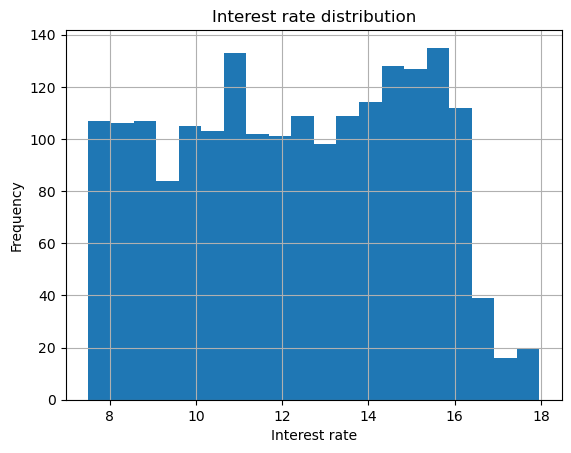

In [32]:
loans_cleaned['interest_rate'].hist(bins=20)
plt.xlabel('Interest rate')
plt.ylabel('Frequency')
plt.title('Interest rate distribution')
plt.show()

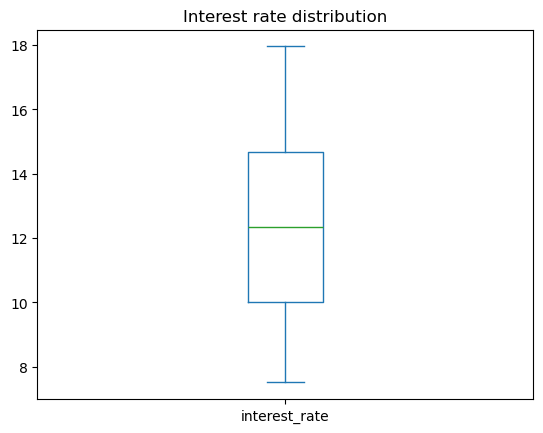

In [33]:
loans_cleaned['interest_rate'].plot(kind='box')
plt.title('Interest rate distribution')
plt.show()

In [34]:
loans_cleaned['interest_rate'] = loans_cleaned['interest_rate'].fillna(loans_cleaned['interest_rate'].mean())

In [39]:
loans_cleaned.duplicated().sum()

np.int64(0)

In [45]:
loans_cleaned['application_date'] = pd.to_datetime(loans_cleaned['application_date'])

In [47]:
loans_cleaned.to_csv('loans_cleaned.csv',index=False)

## Cards

In [27]:
cards_cleaned = cards.copy()

In [28]:
cards_cleaned.head()

,card_id,customer_id,card_type,issue_date,credit_limit,card_status,annual_fee
0,CARD90001,CUST14556,Debit,2025-04-05,NaN,Active,0
1,CARD90002,CUST13413,Debit,2023-05-22,NaN,Active,0
2,CARD90003,CUST11987,Credit,2025-01-05,114600.0,Closed,999
3,CARD90004,CUST13004,Credit,2022-07-19,69400.0,Active,999
4,CARD90005,CUST10584,Credit,2022-02-11,401100.0,Closed,1499


In [29]:
cards_cleaned.describe()

,credit_limit,annual_fee
count,1877.000000,5000.000000
mean,174043.473628,286.715200
std,100508.815482,503.558729
min,12700.000000,0.000000
25%,101800.000000,0.000000
50%,149200.000000,0.000000
75%,218900.000000,499.000000
max,831800.000000,1499.000000


In [30]:
cards_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   card_id       5000 non-null   object 
 1   customer_id   4985 non-null   object 
 2   card_type     5000 non-null   object 
 3   issue_date    4970 non-null   object 
 4   credit_limit  1877 non-null   float64
 5   card_status   4985 non-null   object 
 6   annual_fee    5000 non-null   int64  
dtypes: float64(1), int64(1), object(5)
memory usage: 273.6+ KB


In [31]:
cards_cleaned.isnull().sum()

card_id            0
customer_id       15
card_type          0
issue_date        30
credit_limit    3123
card_status       15
annual_fee         0
dtype: int64

In [32]:
cards_cleaned.shape

(5000, 7)

In [33]:
cards_miss = (cards_cleaned.isnull().sum() / len(cards_cleaned)) * 100
cards_miss

card_id          0.00
customer_id      0.30
card_type        0.00
issue_date       0.60
credit_limit    62.46
card_status      0.30
annual_fee       0.00
dtype: float64

In [34]:
cards_cleaned = cards_cleaned.dropna(subset='customer_id')

In [35]:
print (cards_cleaned['card_type'].unique())

['Debit' 'Credit']


In [36]:
cards_cleaned.groupby('card_type')['credit_limit'].agg(['mean','median'])

,mean,median
card_type,,
Credit,174007.972178,149200.0
Debit,NaN,NaN


In [37]:
cards_limit = cards_cleaned.loc[cards_cleaned['card_type']=='Credit','credit_limit'].dropna()
cards_limit.head()

2    114600.0
3     69400.0
4    401100.0
5    232700.0
7    274000.0
Name: credit_limit, dtype: float64

In [38]:
Q1_ca = cards_limit.quantile(0.25)
Q3_ca = cards_limit.quantile(0.75)
IQR_ca = Q3_ca - Q1_ca
lower_ca = Q1_ca - 1.5 * IQR_ca
upper_ca = Q3_ca + 1.5 * IQR_ca
print(lower_ca)
print(upper_ca)

-73850.0
394550.0


In [39]:
limit_outliers = cards_limit[(cards_limit < lower_ca) | (cards_limit > upper_ca)]
len(limit_outliers)

68

In [40]:
limit_outliers.sort_values()

1862    394800.0
479     395000.0
4664    396700.0
2796    399300.0
2250    400400.0
          ...   
2857    674800.0
1543    713100.0
1577    744500.0
1208    830400.0
472     831800.0
Name: credit_limit, Length: 68, dtype: float64

In [70]:
cards_cleaned.loc[cards_cleaned['card_type']=='Credit','credit_limit'] = (cards_cleaned.loc[cards_cleaned['card_type']=='Credit','credit_limit'].fillna(cards_cleaned.loc[cards_cleaned['card_type']=='Credit','credit_limit'].median()))

In [71]:
cards_cleaned.loc[cards_cleaned['card_type']=='Credit','credit_limit'].isnull().sum()

np.int64(0)

In [74]:
cards_cleaned['issue_date'] = pd.to_datetime(cards_cleaned['issue_date'])

In [75]:
cards_cleaned['issue_date'] = cards_cleaned['issue_date'].fillna(cards_cleaned['issue_date'].median())

In [79]:
cards_cleaned.groupby('card_type')['card_status'].agg(lambda x:x.mode()[0])

card_type
Credit    Active
Debit     Active
Name: card_status, dtype: object

In [83]:
cards_cleaned['card_status'] = cards_cleaned['card_status'].fillna('Active')

In [84]:
cards_cleaned.isnull().sum()

card_id            0
customer_id        0
card_type          0
issue_date         0
credit_limit    3105
card_status        0
annual_fee         0
dtype: int64

In [85]:
cards_cleaned.duplicated().sum()

np.int64(0)

In [86]:
cards_cleaned.dtypes

card_id                 object
customer_id             object
card_type               object
issue_date      datetime64[ns]
credit_limit           float64
card_status             object
annual_fee               int64
dtype: object

In [87]:
cards_cleaned.to_csv('cards_cleaned.csv',index=False)

## Accounts

In [3]:
accounts_cleaned = accounts.copy()

In [4]:
accounts_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6000 entries, 0 to 5999
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   account_id      6000 non-null   object 
 1   customer_id     5964 non-null   object 
 2   account_type    6000 non-null   object 
 3   opening_date    6000 non-null   object 
 4   balance         5928 non-null   float64
 5   account_status  5940 non-null   object 
dtypes: float64(1), object(5)
memory usage: 281.4+ KB


In [5]:
accounts_cleaned.describe()

,balance
count,5.928000e+03
mean,7.682752e+04
std,1.014960e+05
min,-5.000000e+02
25%,2.328231e+04
50%,4.532543e+04
75%,8.939956e+04
max,1.500000e+06


In [6]:
accounts_cleaned['opening_date'] = pd.to_datetime(accounts_cleaned['opening_date'],format='mixed',dayfirst=True)

In [7]:
accounts_cleaned.isnull().sum()

account_id         0
customer_id       36
account_type       0
opening_date       0
balance           72
account_status    60
dtype: int64

In [8]:
accounts_cleaned = accounts_cleaned.dropna(subset='customer_id')

In [9]:
accounts_cleaned['balance'].agg(['mean','median'])

mean      76818.940774
median    45249.490000
Name: balance, dtype: float64

In [21]:
Q1_a = accounts_cleaned['balance'].quantile(0.25)
Q3_a = accounts_cleaned['balance'].quantile(0.75)
IQR_a = Q3_a - Q1_a
lower_a = Q1_a - 1.5 * IQR_a
upper_a = Q3_a + 1.5 * IQR_a
print(lower_a)
print(upper_a)

-75789.47875000001
188414.29125


In [22]:
balance_outliers = accounts_cleaned[(accounts_cleaned['balance'] < lower_a) | (accounts_cleaned['balance'] > upper_a)]
len(balance_outliers)

494

In [23]:
balance_outliers

,account_id,customer_id,account_type,opening_date,balance,account_status
3,ACC20004,CUST14856,Salary,2023-06-02,342076.89,Active
4,ACC20005,CUST13336,Savings,2022-07-08,726233.58,Active
8,ACC20009,CUST14926,Premium Savings,2026-04-30,211917.86,Active
31,ACC20032,CUST14917,Savings,2025-09-13,321717.87,Active
37,ACC20038,CUST11342,Savings,2024-12-01,224757.32,Active
...,...,...,...,...,...,...
5923,ACC25924,CUST13818,Savings,2021-01-21,530416.02,Closed
5933,ACC25934,CUST12715,Premium Savings,2025-06-24,354302.59,Dormant
5967,ACC25968,CUST12131,Savings,2024-03-11,216531.24,Closed
5991,ACC25992,CUST14832,Salary,2025-05-09,220494.79,Closed


In [41]:
accounts_cleaned['balance'] = accounts_cleaned['balance'].fillna(accounts_cleaned['balance'].median())

In [43]:
accounts_cleaned['account_status'].mode()

0    Active
Name: account_status, dtype: object

In [46]:
accounts_cleaned['account_status'] = accounts_cleaned['account_status'].fillna('Active')

In [47]:
accounts_cleaned.isnull().sum()

account_id        0
customer_id       0
account_type      0
opening_date      0
balance           0
account_status    0
dtype: int64

In [49]:
accounts_cleaned.duplicated().sum()

np.int64(0)

In [50]:
accounts_cleaned.columns

Index(['account_id', 'customer_id', 'account_type', 'opening_date', 'balance',
       'account_status'],
      dtype='object')

In [51]:
accounts_cleaned.to_csv('accounts_cleaned.csv',index=False)

## Finnal Data Validation 

In [5]:
print("Customers:",customers_cleaned.duplicated().sum())
print("Transactions:",transactions_cleaned.duplicated().sum())
print("Loans:",loans_cleaned.duplicated().sum())
print("Cards:",cards_cleaned.duplicated().sum())

Customers: 0
Transactions: 0
Loans: 0
Cards: 0


In [8]:
print("Customers:",customers_cleaned['customer_id'].duplicated().sum())
print("Transactions:",transactions_cleaned['transaction_id'].duplicated().sum())
print("Loans:",loans_cleaned['loan_id'].duplicated().sum())
print("Cards:",cards_cleaned['card_id'].duplicated().sum())

Customers: 0
Transactions: 0
Loans: 0
Cards: 0


In [12]:
print(customers_cleaned.dtypes)
print()
print(transactions_cleaned.dtypes)
print()
print(loans_cleaned.dtypes)
print()
print(cards_cleaned.dtypes)

customer_id                 object
age                          int64
gender                      object
city                        object
occupation                  object
annual_income              float64
signup_date         datetime64[ns]
customer_segment            object
dtype: object

transaction_id                   object
account_id                       object
transaction_date         datetime64[ns]
transaction_type                 object
transaction_amount              float64
transaction_direction            object
transaction_status               object
channel                          object
merchant_category                object
amount_issue                     object
dtype: object

loan_id                     object
customer_id                 object
loan_type                   object
loan_amount                float64
interest_rate              float64
tenure_months                int64
loan_status                 object
application_date    datetime64[ns]
dtype: obj

In [3]:
customers_cleaned['signup_date'] = pd.to_datetime(customers_cleaned['signup_date'])

In [4]:
transactions_cleaned['transaction_date'] = pd.to_datetime(transactions_cleaned['transaction_date'],format='mixed', dayfirst=True)

In [5]:
loans_cleaned['application_date'] = pd.to_datetime(loans_cleaned['application_date'])

In [6]:
cards_cleaned['issue_date'] = pd.to_datetime(cards_cleaned['issue_date'])

## Business/Logical Validation

In [28]:
# Transaction Amount Check

len(transactions_cleaned[transactions_cleaned['transaction_amount'] <= 0])

47

In [29]:
transactions_cleaned[transactions_cleaned['transaction_amount'] <= 0][['transaction_amount','transaction_type','transaction_direction','transaction_status']]

,transaction_amount,transaction_type,transaction_direction,transaction_status
1776,0.0,ATM,Credit,Failed
2283,0.0,UPI,Credit,Successful
2512,-100.0,POS,Debit,Failed
2542,0.0,IMPS,Credit,Successful
2938,-100.0,Cash Withdrawal,Debit,Pending
3132,0.0,POS,Debit,Successful
3294,0.0,UPI,Debit,Successful
3679,0.0,Cash Deposit,Credit,Successful
3959,0.0,UPI,Debit,Successful
4195,0.0,IMPS,Debit,Successful


In [34]:
transactions_cleaned[transactions_cleaned['transaction_amount'] <= 0].groupby(
    ['transaction_amount','transaction_type','transaction_direction','transaction_status']).size()

transaction_amount  transaction_type  transaction_direction  transaction_status
-100.0              ATM               Debit                  Reversed              1
                                                             Successful            2
                    Cash Deposit      Debit                  Successful            1
                    Cash Withdrawal   Credit                 Successful            1
                                      Debit                  Pending               1
                    NEFT              Credit                 Successful            1
                                      Debit                  Successful            1
                    POS               Credit                 Successful            2
                                      Debit                  Failed                1
                    UPI               Debit                  Successful            1
 0.0                ATM               Credit                 Failed   

In [33]:
transactions_cleaned[transactions_cleaned['transaction_amount'] <= 0]['transaction_status'].value_counts()

transaction_status
Successful    40
Failed         3
Pending        2
Reversed       2
Name: count, dtype: int64

In [38]:
transactions_cleaned['amount_issue']= np.where((transactions_cleaned['transaction_amount'] <= 0) &
                                               (transactions_cleaned['transaction_status'] =='Successfull'),
                                               'Data error','Valid')

In [8]:
transactions_cleaned.head()

,transaction_id,account_id,transaction_date,transaction_type,transaction_amount,transaction_direction,transaction_status,channel,merchant_category,amount_issue
0,TXN50001,ACC22000,2025-11-26 02:38:00,POS,1919.02,Credit,Successful,POS,Groceries,Valid
1,TXN50002,ACC20749,2025-05-07 20:20:00,Bill Payment,3050.39,Debit,Reversed,POS,Other,Valid
2,TXN50003,ACC22844,2025-10-04 17:14:00,UPI,169.18,Credit,Failed,POS,Utilities,Valid
3,TXN50004,ACC24753,2025-09-01 14:58:00,Cash Withdrawal,2385.53,Debit,Successful,ATM,Other,Valid
4,TXN50005,ACC24906,2025-01-15 18:59:00,IMPS,631.12,Debit,Successful,Mobile App,Dining,Valid


## EDA

### Data overview

### Numerical Analysis

In [14]:
customers_cleaned.describe(include='number')

,age,annual_income
count,5000.000000,5.000000e+03
mean,36.681600,6.758863e+05
std,10.755099,4.849433e+05
min,18.000000,4.120000e+04
25%,29.000000,3.652750e+05
50%,36.000000,5.534500e+05
75%,44.000000,8.359000e+05
max,75.000000,6.579800e+06


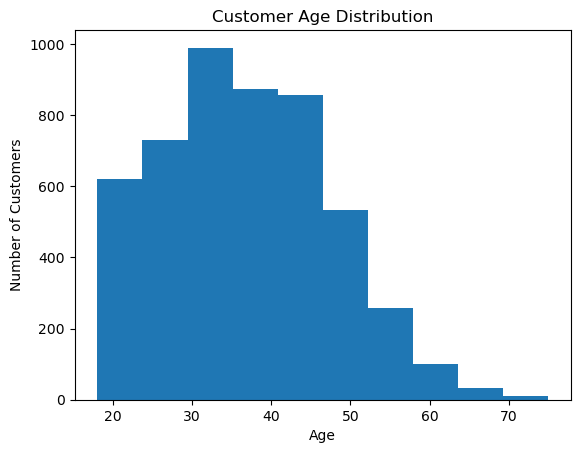

In [17]:
# Age
plt.hist(customers_cleaned['age'],bins=10)
plt.xlabel('Age')
plt.ylabel('Number of Customers')
plt.title('Customer Age Distribution')
plt.show()

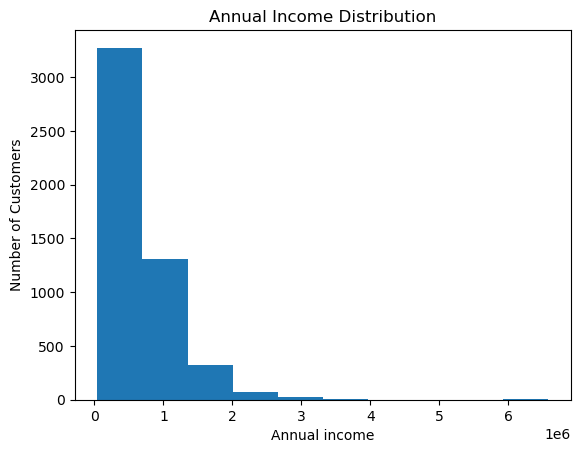

In [19]:
# Annual Income

plt.hist(customers_cleaned['annual_income'],bins=10)
plt.xlabel('Annual income')
plt.ylabel('Number of Customers')
plt.title('Annual Income Distribution')
plt.show()

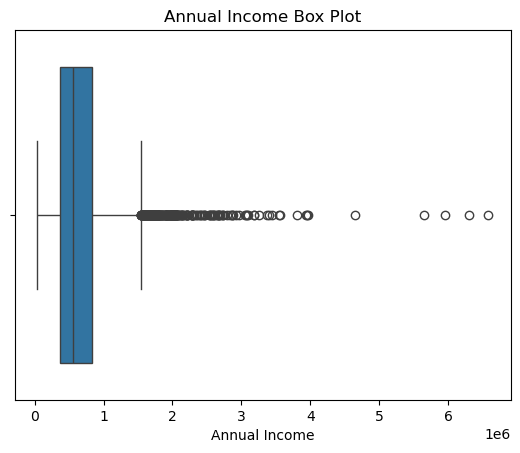

In [20]:
# Annual Income 

sns.boxplot(x=customers_cleaned['annual_income'])
plt.xlabel('Annual Income')
plt.title('Annual Income Box Plot')
plt.show()

### Categorical Analysis

In [43]:
#Gender
customers_cleaned['gender'].value_counts()

gender
Male      2644
Female    2246
Other      110
Name: count, dtype: int64

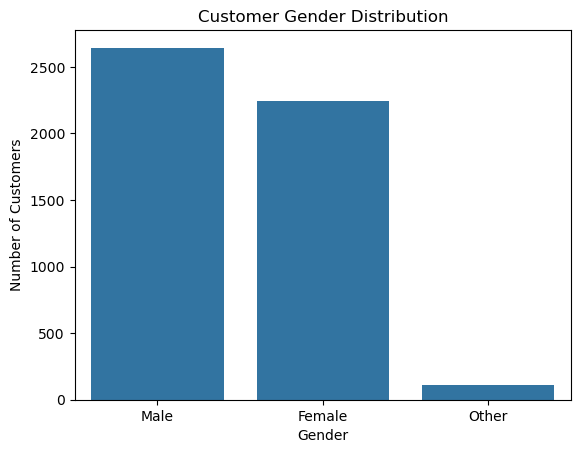

In [25]:
sns.countplot(data=customers_cleaned,x='gender')
plt.xlabel('Gender')
plt.ylabel('Number of Customers')
plt.title('Customer Gender Distribution')
plt.show()

In [42]:
customers_cleaned['gender'].value_counts(normalize=True)*100

gender
Male      52.88
Female    44.92
Other      2.20
Name: proportion, dtype: float64

In [30]:
customers_cleaned['city'].value_counts()

city
Vellore        413
Chennai        353
Mumbai         348
Bengaluru      341
Coimbatore     340
Trichy         338
Pune           334
Madurai        325
Delhi          324
Kochi          318
Salem          315
Hyderabad      314
Erode          313
Tirunelveli    313
Thanjavur      311
Name: count, dtype: int64

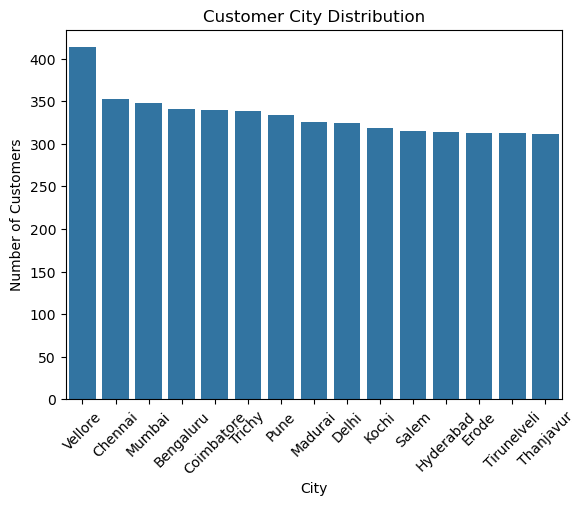

In [38]:
order = customers_cleaned['city'].value_counts().index
sns.countplot(data=customers_cleaned,x='city',order=order)
plt.xlabel('City')
plt.ylabel('Number of Customers')
plt.title('Customer City Distribution')
plt.xticks(rotation=45)
plt.show()

In [41]:
customers_cleaned['city'].value_counts(normalize=True)*100

city
Vellore        8.26
Chennai        7.06
Mumbai         6.96
Bengaluru      6.82
Coimbatore     6.80
Trichy         6.76
Pune           6.68
Madurai        6.50
Delhi          6.48
Kochi          6.36
Salem          6.30
Hyderabad      6.28
Erode          6.26
Tirunelveli    6.26
Thanjavur      6.22
Name: proportion, dtype: float64

In [33]:
customers_cleaned['occupation'].value_counts()

occupation
Salaried          2111
Self-Employed      880
Student            616
Freelancer         504
Business Owner     499
Retired            390
Name: count, dtype: int64

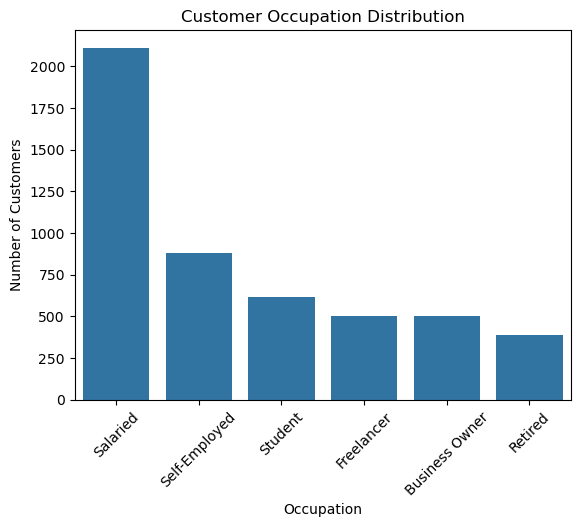

In [37]:
order = customers_cleaned['occupation'].value_counts().index
sns.countplot(data=customers_cleaned,x='occupation',order=order)
plt.xlabel('Occupation')
plt.ylabel('Number of Customers')
plt.title('Customer Occupation Distribution')
plt.xticks(rotation=45)
plt.show()

In [40]:
customers_cleaned['occupation'].value_counts(normalize=True)*100

occupation
Salaried          42.22
Self-Employed     17.60
Student           12.32
Freelancer        10.08
Business Owner     9.98
Retired            7.80
Name: proportion, dtype: float64

### Categorical -> Numerical Analysis

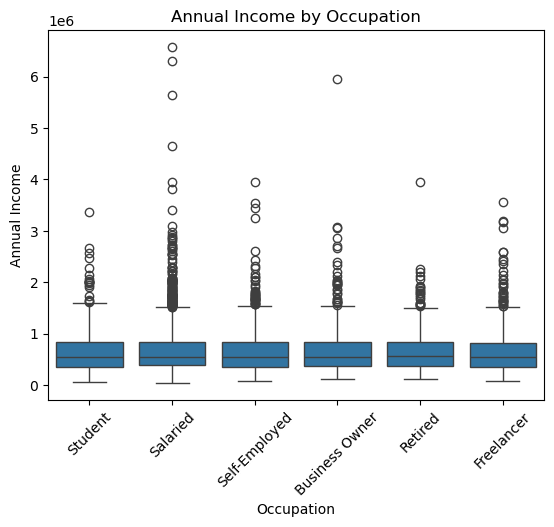

In [45]:
# Occupation Vs Annual Income

sns.boxplot(data=customers_cleaned,x='occupation',y='annual_income')
plt.xlabel('Occupation')
plt.ylabel('Annual Income')
plt.title('Annual Income by Occupation')
plt.xticks(rotation=45)
plt.show()

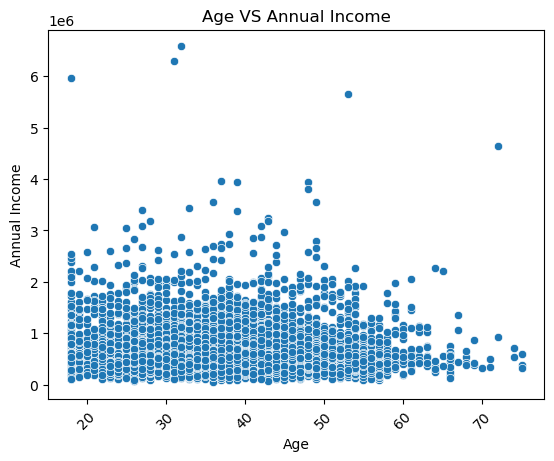

In [46]:
# Age Vs Annual Income

sns.scatterplot(data=customers_cleaned,x='age',y='annual_income')
plt.xlabel('Age')
plt.ylabel('Annual Income')
plt.title('Age VS Annual Income')
plt.xticks(rotation=45)
plt.show()

In [47]:
customers_cleaned[['age','annual_income']].corr()

,age,annual_income
age,1.000000,-0.008905
annual_income,-0.008905,1.000000


In [10]:
print(customers_cleaned.columns)
print(loans_cleaned.columns)

Index(['customer_id', 'age', 'gender', 'city', 'occupation', 'annual_income',
       'signup_date', 'customer_segment'],
      dtype='object')
Index(['loan_id', 'customer_id', 'loan_type', 'loan_amount', 'interest_rate',
       'tenure_months', 'loan_status', 'application_date'],
      dtype='object')


In [50]:
# Merge
loan_analysis = loans_cleaned.merge(customers_cleaned[['customer_id','annual_income']], on='customer_id', how= 'left')

In [12]:
loan_analysis[['customer_id','annual_income','loan_amount']].head()

,customer_id,annual_income,loan_amount
0,CUST12666,579400.0,277100.0
1,CUST11477,1979500.0,305000.0
2,CUST12832,553450.0,1275600.0
3,CUST11308,338800.0,825800.0
4,CUST13599,372000.0,1565300.0


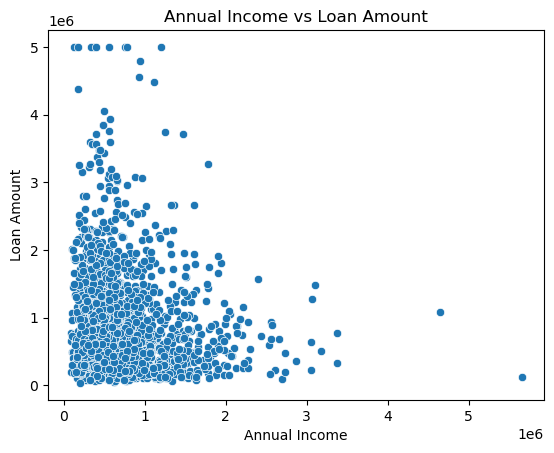

In [13]:
# Loan Amount and Annual Income

sns.scatterplot(data=loan_analysis,x='annual_income',y='loan_amount')
plt.xlabel('Annual Income')
plt.ylabel('Loan Amount')
plt.title('Annual Income vs Loan Amount')
plt.show()

In [15]:
loan_analysis[['annual_income','loan_amount']].corr()

,annual_income,loan_amount
annual_income,1.000000,-0.060969
loan_amount,-0.060969,1.000000


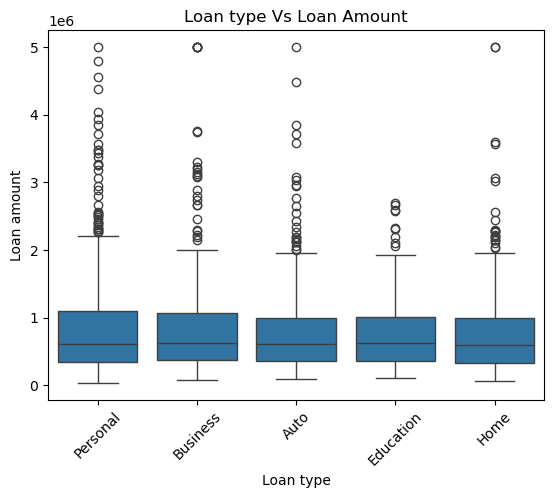

In [17]:
# Loan type vs Loan amount

sns.boxplot(data=loans_cleaned,x='loan_type',y='loan_amount')
plt.xlabel('Loan type')
plt.xticks(rotation=45)
plt.ylabel('Loan amount')
plt.title('Loan type Vs Loan Amount')
plt.show()

In [18]:
loans_cleaned.groupby('loan_type')['loan_amount'].agg(['count','mean','median','min','max'])

,count,mean,median,min,max
loan_type,,,,,
Auto,309,816425.889968,612250.0,85900.0,5000000.0
Business,330,888600.151515,625050.0,79300.0,5000000.0
Education,194,789949.226804,621550.0,105500.0,2692700.0
Home,390,785492.820513,593900.0,58900.0,5000000.0
Personal,762,830884.317585,612225.0,33100.0,5000000.0


In [23]:
# Card type Vs Credit limit
credit_cards = cards_cleaned[cards_cleaned['card_type']=='Credit']

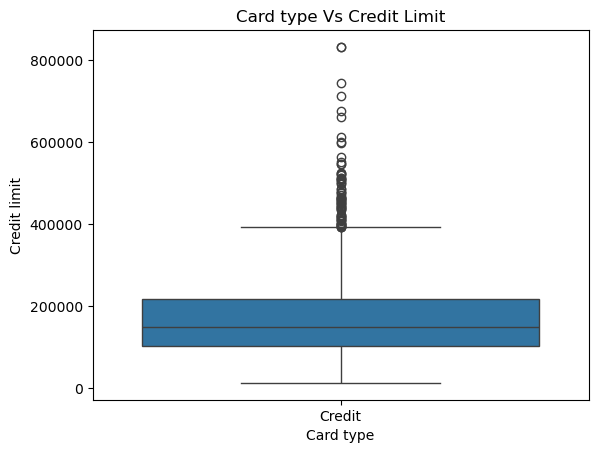

In [25]:
sns.boxplot(data=credit_cards,x='card_type',y='credit_limit')
plt.xlabel('Card type')
plt.ylabel('Credit limit')
plt.title('Card type Vs Credit Limit')
plt.show()

In [28]:
cards_cleaned['card_type'].value_counts()

card_type
Debit     3105
Credit    1880
Name: count, dtype: int64

In [29]:
cards_cleaned['card_type'].value_counts(normalize=True)*100

card_type
Debit     62.286861
Credit    37.713139
Name: proportion, dtype: float64

In [30]:
# Transaction Analysis
## Transaction Type Distribution

transactions_cleaned['transaction_type'].value_counts()

transaction_type
UPI                8473
POS                5378
ATM                3640
IMPS               3533
Bill Payment       2617
NEFT               2336
Cash Deposit       2148
Cash Withdrawal    1795
Name: count, dtype: int64

In [31]:
transactions_cleaned['transaction_type'].value_counts(normalize=True)*100

transaction_type
UPI                28.318850
POS                17.974599
ATM                12.165775
IMPS               11.808155
Bill Payment        8.746658
NEFT                7.807487
Cash Deposit        7.179144
Cash Withdrawal     5.999332
Name: proportion, dtype: float64

In [32]:
### Transaction Status Analysis

transactions_cleaned['transaction_status'].value_counts()

transaction_status
Successful    26045
Pending        1464
Failed         1256
Reversed       1155
Name: count, dtype: int64

In [33]:
transactions_cleaned['transaction_status'].value_counts(normalize=True)*100

transaction_status
Successful    87.048797
Pending        4.893048
Failed         4.197861
Reversed       3.860294
Name: proportion, dtype: float64

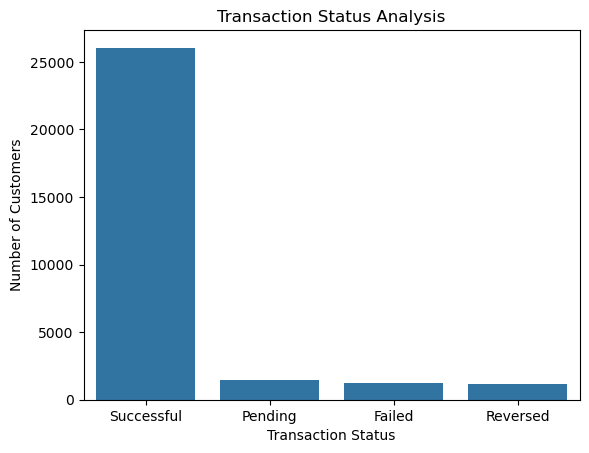

In [35]:
order = transactions_cleaned['transaction_status'].value_counts().index
sns.countplot(data=transactions_cleaned,x='transaction_status',order=order)
plt.xlabel('Transaction Status')
plt.ylabel('Number of Customers')
plt.title('Transaction Status Analysis')
plt.show()

In [37]:
# Transaction type Vs Transation amount

transactions_cleaned.groupby('transaction_type')['transaction_amount'].agg(['count','mean','median'])

,count,mean,median
transaction_type,,,
ATM,3640,3240.797591,1773.255
Bill Payment,2617,3147.110103,1762.920
Cash Deposit,2148,3233.098210,1809.225
Cash Withdrawal,1795,3185.389131,1705.060
IMPS,3533,3233.674495,1833.720
NEFT,2336,3295.398780,1802.185
POS,5378,3332.104365,1824.555
UPI,8473,3159.343248,1729.700


In [38]:
# Transaction type vs Transaction Status

pd.crosstab(transactions_cleaned['transaction_type'],transactions_cleaned['transaction_status'])

transaction_status,Failed,Pending,Reversed,Successful
transaction_type,,,,
ATM,145,139,153,3203
Bill Payment,83,121,94,2319
Cash Deposit,87,104,78,1879
Cash Withdrawal,83,95,83,1534
IMPS,148,181,140,3064
NEFT,102,110,90,2034
POS,225,284,195,4674
UPI,383,430,322,7338


In [41]:
success_rate = pd.crosstab(transactions_cleaned['transaction_type'],transactions_cleaned['transaction_status'],normalize='index')*100
success_rate

transaction_status,Failed,Pending,Reversed,Successful
transaction_type,,,,
ATM,3.983516,3.818681,4.203297,87.994505
Bill Payment,3.171571,4.623615,3.591899,88.612916
Cash Deposit,4.050279,4.841713,3.631285,87.476723
Cash Withdrawal,4.623955,5.292479,4.623955,85.459610
IMPS,4.189074,5.123125,3.962638,86.725163
NEFT,4.366438,4.708904,3.852740,87.071918
POS,4.183711,5.280774,3.625883,86.909632
UPI,4.520241,5.074944,3.800307,86.604508


In [42]:
# Transaction Amount by status

transactions_cleaned.groupby('transaction_status')['transaction_amount'].agg(['count','mean','median'])

,count,mean,median
transaction_status,,,
Failed,1256,3543.936485,1776.075
Pending,1464,3507.614232,1695.465
Reversed,1155,3054.016736,1801.120
Successful,26045,3201.882672,1776.075


In [43]:
# Loan Status Distribution

loans_cleaned['loan_status'].value_counts()

loan_status
Active       1024
Closed        519
Pending       295
Defaulted     147
Name: count, dtype: int64

In [44]:
loans_cleaned['loan_status'].value_counts(normalize=True)*100

loan_status
Active       51.586902
Closed       26.146096
Pending      14.861461
Defaulted     7.405542
Name: proportion, dtype: float64

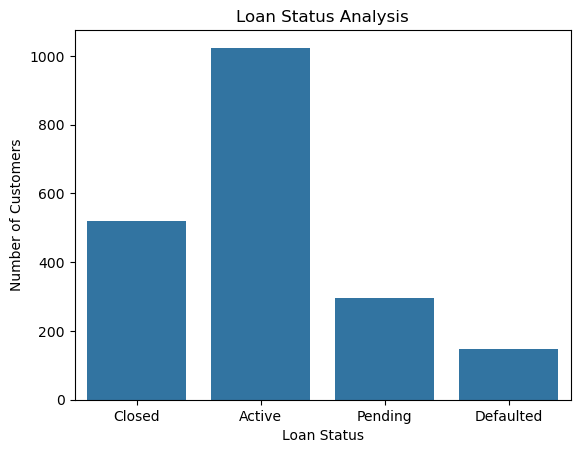

In [45]:
sns.countplot(data=loans_cleaned,x='loan_status')
plt.xlabel('Loan Status')
plt.ylabel('Number of Customers')
plt.title('Loan Status Analysis')
plt.show()

In [46]:
# Loan type vs loan Status

pd.crosstab(loans_cleaned['loan_type'],loans_cleaned['loan_status'])

loan_status,Active,Closed,Defaulted,Pending
loan_type,,,,
Auto,167,69,25,48
Business,170,85,23,52
Education,95,46,14,39
Home,190,115,29,56
Personal,402,204,56,100


In [47]:
pd.crosstab(loans_cleaned['loan_type'],loans_cleaned['loan_status'],normalize='index')*100

loan_status,Active,Closed,Defaulted,Pending
loan_type,,,,
Auto,54.045307,22.330097,8.090615,15.533981
Business,51.515152,25.757576,6.969697,15.757576
Education,48.969072,23.711340,7.216495,20.103093
Home,48.717949,29.487179,7.435897,14.358974
Personal,52.755906,26.771654,7.349081,13.123360


In [51]:
# Monthly Transaction
transactions_cleaned['transaction_month'] = transactions_cleaned['transaction_date'].dt.strftime('%B')

In [57]:
month_order= ['January','February','March','April','May','June','July','August','September','October','November','December']
monthly_transaction = ( transactions_cleaned['transaction_month'].value_counts().reindex(month_order) )
monthly_transaction

transaction_month
January      2512
February     2342
March        2564
April        2483
May          2524
June         2497
July         2487
August       2609
September    2404
October      2511
November     2440
December     2547
Name: count, dtype: int64

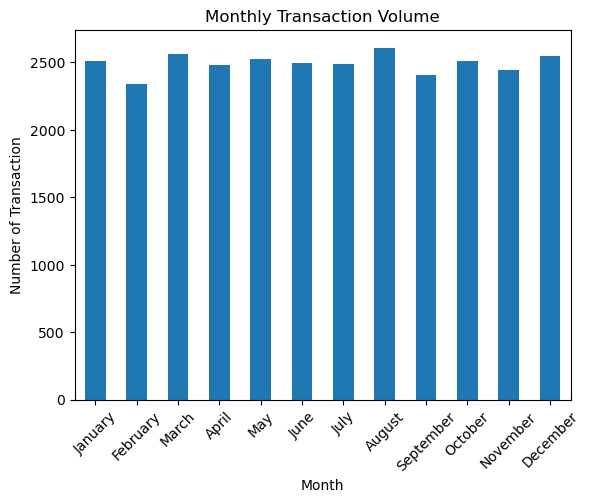

In [58]:
monthly_transaction.plot(kind='bar')
plt.xlabel('Month')
plt.ylabel('Number of Transaction')
plt.title('Monthly Transaction Volume')
plt.xticks(rotation=45)
plt.show()

In [60]:
# Monthly amount

monthly_amount =(transactions_cleaned.groupby('transaction_month')['transaction_amount'].sum().reindex(month_order))
monthly_amount

transaction_month
January      7762069.155
February     7298093.690
March        8124387.520
April        8230873.560
May          7958342.165
June         8087120.790
July         7834606.245
August       8252776.975
September    7760653.075
October      9241551.840
November     7933229.685
December     8023050.270
Name: transaction_amount, dtype: float64

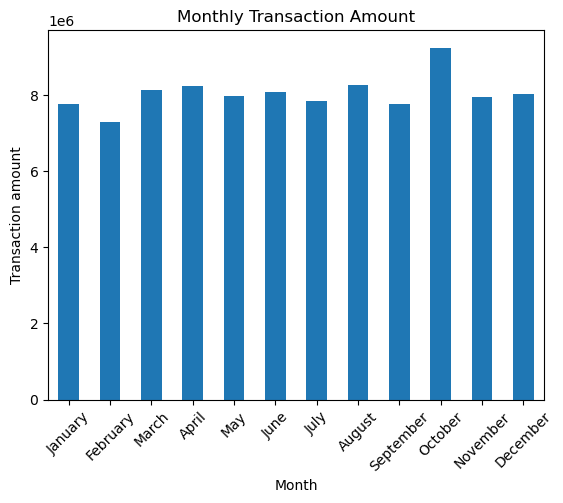

In [62]:
monthly_amount.plot(kind='bar')
plt.xlabel('Month')
plt.ylabel('Transaction amount')
plt.title('Monthly Transaction Amount')
plt.xticks(rotation=45)
plt.show()

In [72]:
customers_cleaned.columns

Index(['customer_id', 'age', 'gender', 'city', 'occupation', 'annual_income',
       'signup_date', 'customer_segment'],
      dtype='object')

In [33]:
transactions_cleaned.head()

,transaction_id,account_id,transaction_date,transaction_type,transaction_amount,transaction_direction,transaction_status,channel,merchant_category,amount_issue,transaction_month
0,TXN50001,ACC22000,2025-11-26 02:38:00,POS,1919.02,Credit,Successful,POS,Groceries,Valid,November
1,TXN50002,ACC20749,2025-05-07 20:20:00,Bill Payment,3050.39,Debit,Reversed,POS,Other,Valid,May
2,TXN50003,ACC22844,2025-10-04 17:14:00,UPI,169.18,Credit,Failed,POS,Utilities,Valid,October
3,TXN50004,ACC24753,2025-09-01 14:58:00,Cash Withdrawal,2385.53,Debit,Successful,ATM,Other,Valid,September
4,TXN50005,ACC24906,2025-01-15 18:59:00,IMPS,631.12,Debit,Successful,Mobile App,Dining,Valid,January


## Feature Engineering

In [40]:
# Age Group

labels = 'Young Adult','Adult','Middle Age','Senior'
customers_cleaned['age_group'] = pd.cut(customers_cleaned['age'],bins=[17,25,40,60,100],labels=labels)

In [44]:
customers_cleaned[['age','age_group']].head()

,age,age_group
0,31,Adult
1,21,Young Adult
2,39,Adult
3,36,Adult
4,52,Middle Age


In [43]:
# Income Category

customers_cleaned['income_category']= pd.qcut(customers_cleaned['annual_income'],q=3,labels=['Low','Medium','High'])

In [45]:
customers_cleaned[['annual_income','income_category']].head()

,annual_income,income_category
0,279400.0,Low
1,1403300.0,High
2,798400.0,High
3,237200.0,Low
4,872100.0,High


In [46]:
transactions_cleaned['transaction_year']=( transactions_cleaned['transaction_date'].dt.year )

In [48]:
transactions_cleaned[['transaction_date','transaction_year']].head()

,transaction_date,transaction_year
0,2025-11-26 02:38:00,2025
1,2025-05-07 20:20:00,2025
2,2025-10-04 17:14:00,2025
3,2025-09-01 14:58:00,2025
4,2025-01-15 18:59:00,2025


In [54]:
loans_cleaned['loan_to_income_ratio'] = (loan_analysis['loan_amount'] / loan_analysis['annual_income'])

In [55]:
loans_cleaned.head()

,loan_id,customer_id,loan_type,loan_amount,interest_rate,tenure_months,loan_status,application_date,loan_to_income_ratio
0,LOAN70001,CUST12666,Personal,277100.0,13.60,24,Closed,2022-03-30,0.478253
1,LOAN70002,CUST11477,Personal,305000.0,15.82,120,Active,2023-11-25,0.154079
2,LOAN70003,CUST12832,Personal,1275600.0,8.21,60,Pending,2025-04-17,2.304815
3,LOAN70004,CUST11308,Business,825800.0,16.44,48,Closed,2023-03-04,2.437426
4,LOAN70005,CUST13599,Personal,1565300.0,10.49,60,Active,2025-11-23,4.207796


In [56]:
customers_cleaned.to_csv('customers_cleaned.csv',index=False)

In [57]:
transactions_cleaned.to_csv('transactions_cleaned.csv',index=False)

In [58]:
loans_cleaned.to_csv('loans_cleaned.csv',index=False)

In [59]:
cards_cleaned.to_csv('cards_cleaned.csv',index=False)

In [15]:
customers_cleaned[customers_cleaned['signup_date'].astype(str).str.match(r"^\d{2}-\d{2}-\d{4}$")]

,customer_id,age,gender,city,occupation,annual_income,signup_date,customer_segment,age_group,income_category
